# Final exam

__<div style="text-align: right"> EE370: Software lab, Kyung Hee University. </div>__
_<div style="text-align: right"> Jong-Han Kim (jonghank@khu.ac.kr) </div>_

This is a 24 hour take-home exam. Completed works should be turned in to the instructor and the course assistant no later than 2:00pm on December 21st, and _you are not allowed to discuss the exam with anyone_ until then. The only exception is when you email the instructor for clarification.

Write your student ID and name below. _Typing your name implies that "you affirm that you did not give or receive any unauthorized help on this exam, and that all the works are your own."_

<br>

- STUDENT ID:

- STUDENT NAME:

<br>

The exam consists of two questions. You should work on both of them. Your answers should be as concise as possible while self-explaining you made correct results. Poorly presented answers, for which the grader has to closely examine or even run the code to check the correctness, will be deducted.

<br>

---
## Document recommendation system

You are given a corpus (collection) of 500 Wikipedia pages, collected from weekly lists of the most popular pages for the past nine months.

The data set was preprocessed as follows, which will give you a idea of how you can interpret and handle the data.

- First, the section titles and reference sections (bibliography, notes, references, further reading) from each document were removed.
- Then each document was converted to a list of words. The conversion removes numbers and stop words (short or common words such as 'the'/'is'/'that'/'what'), and applies a stemming (removing endings from words so you can count things like 'work'/'works'/'worked' together) algorithm to nouns and verbs. So each document is now a list of nouns and verbs.
- We then formed a _dictionary_ of all the words that appear in at least 20 documents. The dictionary contains 4423 words (nouns and verbs).
- Using this dictionary, we can represent each document in the corpus by a (normalized) _word histogram vector_ of length 4423. The word histogram vector can be interpreted as a feature vector for a document for this problem.


Running the following cell loads the following arrays:

- `titles` : The list of titles of the documents. For example `title[i]` returns the title of the `i`-th document, where `i` ranges from 0 to 499.
- `dictionary` : The list of 4423 words used for this problem, so each of these words appears in at least 20 documents.
- `word_histogram` : This is a 500x4423 matrix where each row represents the (normalized) word histogram of a document. For example, `word_histogram[i]` returns a 4423 dimensional word histogram vector for document `i`, and `word_histogram[i,j]` describes how frequently the `j`-th word (the word in `dictionary[j]`) appears in document `i`. So `word_histogram[i,j]` is zero if the word `dictionary[j]` does not appear in document `i`, and `word_histogram[i,j]` is high if the word `dictionary[j]` appears in document `i` many times.


In [ ]:
import numpy as np
import json, urllib.request

url = "https://jonghank.github.io/ee370/files/documents_data.json"
data = urllib.request.urlopen(url).read().decode()
obj = json.loads(data)

word_histogram = np.array([ obj["articles"][i] for i in range(500) ])
dictionary = obj["dictionary"]
titles = obj["titles"]

<br>

**_(Problem 1a)_** This is a warm-up problem. What is the title of the last document? What are the 20 most frequently appearing words in the last document? Google the name in the resulting title (or "Princess Leia") to figure out who she is, and check if your results make sense.

In [ ]:
# your code here


<br>

**_(Problem 1b)_** Fit the $k$-means model with $K=9$ (nine clusters).
You may make use of the `KMeans` function from the `scikit-learn` Python machine learning package (https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans).

Summarize your clustering results by clearly displaying the followings, and present short discussions on your results.

 For each of the $K$ clusters,
- Show 10 most frequently appearing words in each cluster representative.
- Show the number of articles in each cluster.
- Show the titles of the ten articles closest to the cluster representative.
- Briefly explain your results, characterizing each of the $K$ clusters.

_Note that the $k$-means algorithm does not always give you the globally optimal solution, in other words it may return similar but slightly different solutions for each run. Please re-run the clustering until every cluster has at least 10 documents. You may need more than 10 runs for such results._

In [ ]:
# your code here


In [ ]:
# your code here


<br>

**_(Problem 1c)_** You started a web service called the 'Kiwipedia', which goes like this.

- When a user is reading a web article, your service opens an annoying pop-up window with an ugly Kiwi-bot character in it suggesting five Wikipedia pages that the current user will most probably be interested in.
- This is important since you will get paid by the number of incoming clicks via your service.
- Since there is no other direct ways to guess the users' preferences, you just assume that s/he will prefer popular Wikipedia pages with topics similar to the current webpage.

Explain in details how you will use the results obtained in the previous subproblems in order to implement your idea.

In [ ]:
# your answer here


<br>

**_(Problem 1d)_** Now implement your idea. Suppose a user is currently at a webpage, which can be characterized by a 4423 dimensional word histogram vector, `word_histogram_current_page`, given below. The word histogram uses the same 4423-word dictionary you used in the previous subproblems.

List the titles of the five pages that you will have your Kiwi-bot to display in your pop-up window.

_Though your instructor computed and gave the word histogram vector for you today, everyone in this class should now be able to build this vector on your own from the raw webpage._

In [ ]:
word_histogram_current_page = np.array(obj["article_crnt"])

# your code here


<br>

<br>

---

## Stage illumination

A concert hall has a square stage that is divided into $m$ pixels (or regions), and we want to illuminate the stage by using $n$ fixed lamps which are located below the ceiling (but with different heights). We let $y_i$ denote the lighting level in pixel $i$, so the $m$-vector $y$ gives the illumination levels on the stage. We let $x_i$ denote the power level at which lamp $i$ operates, so the $n$-vector $x$ gives the set of lamp powers.

The vector of illumination levels on the stage is a linear function of the lamp powers, so we have $y = Ax$ for some $m\times n$ matrix $A$. The $j$th column of $A$ gives the illumination pattern for lamp $j$, that is, the illumination when lamp $j$ has unit power and all other lamps are off, so it is determined by the relative geometry between the $j$th lamp and the stage surfaces. We assume that $m\gg n$ so we use way smaller number of lamps compared to the number of pixels that we divide the stage into. The $i$th row of $A$ gives the sensitivity of pixel $i$ to the $n$ lamp powers.

The following cell defines the locations of 10 lamps, and builds the matrix $A$ that maps the lamp powers, $x$, to the illumination on the stage floor, $y$. The plot for example shows the achieved stage illumination pattern with the lamp locations, when Lamp-0 and Lamp-6 are on (with specific powers). So it is like the stage seen from the ceiling.


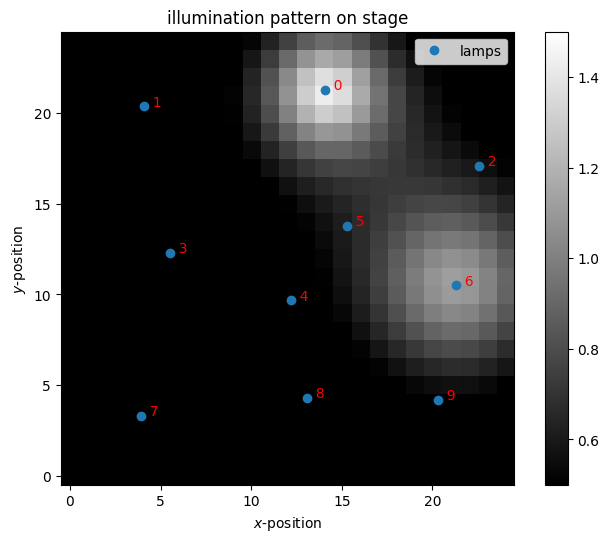

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 25
m = N*N
pix_x = np.arange(0,N).reshape(-1,1)@np.ones((1,N))
pix_y = np.ones((N,1))@np.arange(0,N).reshape(1,-1)
pixels = np.hstack(( pix_x.reshape(m,1), pix_y.reshape(m,1), \
                    np.zeros((m,1)) ))

n = 10
lamp_positions = np.array([[14.1, 21.3, 3.5],  # [x-pos, y_pos, height]
                           [ 4.1, 20.4, 4.0],  # for 10 lamps
                           [22.6, 17.1, 6.0],
                           [ 5.5, 12.3, 4.0],
                           [12.2,  9.7, 4.0],
                           [15.3, 13.8, 6.0],
                           [21.3, 10.5, 5.5],
                           [ 3.9,  3.3, 5.0],
                           [13.1,  4.3, 5.0],
                           [20.3,  4.2, 4.5]])
A = np.zeros((m,n))
for i in range(m):
  for j in range(n):
    A[i,j] = 1.0 / np.linalg.norm(pixels[i,:]-lamp_positions[j,:])**2
A *= m/np.sum(A)

x_ex = np.zeros(n)    # example
x_ex[0] = 1.5         # lamp-1 on with power=1.5
x_ex[6] = 3.0         # lamp-4 on with power=3.0
y_ex = A.dot(x_ex)    # illumination on stage

plt.figure(figsize=(8,6), dpi=100)
plt.imshow(y_ex.reshape(N,N).T, cmap='gray', origin='lower')
plt.plot(lamp_positions[:,0], lamp_positions[:,1], 'o', label='lamps')
for i in range(n):
  plt.text(lamp_positions[i,0],lamp_positions[i,1], f"  {i}", color="r" )
plt.colorbar()
plt.clim(0.5,1.5)
plt.xlabel(r'$x$-position')
plt.ylabel(r'$y$-position')
plt.title('illumination pattern on stage')
plt.legend()
plt.show()

<br>

The goal of this problem is to find the vector of lamp powers, $x$, that results in a desired illumination pattern on stage $y^\text{des}$, such as $y^\text{des}= \mathbf{1}$, which is uniform illumination across the stage (the symbol $\mathbf{1}$ represents the one-vector where all of its elements are 1's). In other words we look for $x$ such that $Ax \approx y^\text{des}$. We can solve this by formulating the least squares problem minimizing $\| Ax-y^\text{des} \|_2^2$.

<br>

**_(Problem 2a)_** What is the best lamp powers for uniform illumination across the stage? You may print the numbers out, or show them by a simple plot.

In [ ]:
# your code here


<br>

**_(Problem 2b)_** Display the stage illumination pattern obtained from the above solution, and display the stage illumination pattern obtained from other (non-optimal) simple approaches, for example $x = \mathbf{1}$ (the uniform lamp powers).

Show that the stage illumination pattern obtained from your solution reveals better uniformity. You can compare the histograms of the illumination levels on $m$ pixels for each illumination pattern.

In [ ]:
# your code here
